# Model Comparison

This notebook evaluates and compares all trained machine learning models.

Objectives:

- Load trained models
- Evaluate model performance
- Compare multiple evaluation metrics
- Identify the best-performing model

## Cell 2 — Import Libraries ##

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

## Cell 3 — Load Dataset ##

In [2]:
df = pd.read_csv("../data/processed/selected_data.csv")

print(df.shape)

df.head()

(101766, 29)


,num_lab_procedures,diag_1,diag_2,diag_3,num_medications,time_in_hospital,age,discharge_disposition_id,number_diagnoses,num_procedures,...,metformin,glipizide,glyburide,number_emergency,changed_medications,change,pioglitazone,rosiglitazone,glimepiride,readmitted
0,41,250.83,NaN,NaN,1,1,5,25,1,0,...,No,No,No,0,0,No,No,No,No,0
1,59,276,250.01,255,18,3,15,1,9,0,...,No,No,No,0,1,Ch,No,No,No,1
2,11,648,250,V27,13,2,25,1,6,5,...,No,Steady,No,0,0,No,No,No,No,0
3,44,8,250.43,403,16,2,35,1,7,1,...,No,No,No,0,1,Ch,No,No,No,0
4,51,197,157,250,8,1,45,1,5,0,...,No,Steady,No,0,0,Ch,No,No,No,0


## Cell 4 — Split Features & Target ##

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["readmitted"])
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_test.shape)

(20354, 28)


## Cell 5 — Load Trained Models ##

In [4]:
MODELS_DIR = Path("../models")

trained_models = {
    "Logistic Regression": joblib.load(
        MODELS_DIR / "logistic_regression.pkl"
    ),

    "Decision Tree": joblib.load(
        MODELS_DIR / "decision_tree.pkl"
    ),

    "Random Forest": joblib.load(
        MODELS_DIR / "random_forest.pkl"
    ),

    "XGBoost": joblib.load(
        MODELS_DIR / "xgboost.pkl"
    ),

    "LightGBM": joblib.load(
        MODELS_DIR / "lightgbm.pkl"
    ),

    "CatBoost": joblib.load(
        MODELS_DIR / "catboost.pkl"
    )
}

print(f"{len(trained_models)} models loaded successfully.")

6 models loaded successfully.


## Cell 6 — Evaluation Function ##

In [12]:
def evaluate_model(model_name, pipeline, X_test, y_test):
    """
    Evaluate a trained multiclass classification model.
    """

    # Predictions
    y_pred = pipeline.predict(X_test)

    # Prediction probabilities
    y_prob = pipeline.predict_proba(X_test)

    results = {

        "Model": model_name,

        # Accuracy
        "Accuracy": accuracy_score(y_test, y_pred),

        # Precision
        "Precision (Macro)": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Precision (Weighted)": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        # Recall
        "Recall (Macro)": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Recall (Weighted)": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        # F1
        "F1 Score (Macro)": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "F1 Score (Weighted)": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),

        # ROC AUC
        "ROC AUC": roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        ),

        # Save predictions
        "Predictions": y_pred,
        "Probabilities": y_prob

    }

    return results

## Cell 7 — Evaluate All Models ##

In [13]:
# Evaluate all trained models

evaluation_results = []

for model_name, pipeline in trained_models.items():

    print(f"Evaluating {model_name}...")

    result = evaluate_model(
        model_name=model_name,
        pipeline=pipeline,
        X_test=X_test,
        y_test=y_test
    )

    evaluation_results.append(result)

print("\nAll models evaluated successfully!")

Evaluating Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...

All models evaluated successfully!


## Cell 8 — Create Comparison Table ##

In [15]:
# Create comparison table

results_df = pd.DataFrame(evaluation_results)

# Remove prediction arrays from the summary table
results_df = results_df.drop(
    columns=["Predictions", "Probabilities"]
)

# Sort models by F1 Score
results_df = results_df.sort_values(
    by="F1 Score (Weighted)",
    ascending=False
)

# Reset index
results_df.reset_index(
    drop=True,
    inplace=True
)

# Display results
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision (Macro)": "{:.4f}",
    "Precision (Weighted)": "{:.4f}",
    "Recall (Macro)": "{:.4f}",
    "Recall (Weighted)": "{:.4f}",
    "F1 Score (Macro)": "{:.4f}",
    "F1 Score (Weighted)": "{:.4f}",
    "ROC AUC": "{:.4f}"
})

,Model,Accuracy,Precision (Macro),Precision (Weighted),Recall (Macro),Recall (Weighted),F1 Score (Macro),F1 Score (Weighted),ROC AUC
0,CatBoost,0.5953,0.5421,0.5716,0.4221,0.5953,0.4064,0.5496,0.6952
1,XGBoost,0.5933,0.5241,0.5648,0.4226,0.5933,0.4090,0.5493,0.6897
2,LightGBM,0.5941,0.5450,0.5717,0.4219,0.5941,0.4070,0.5488,0.6935
3,Random Forest,0.5838,0.5487,0.5638,0.4043,0.5838,0.3808,0.5293,0.6770
4,Logistic Regression,0.5769,0.4971,0.5425,0.4032,0.5769,0.3858,0.5250,0.6527
5,Decision Tree,0.4984,0.3972,0.4908,0.3953,0.4984,0.3959,0.4944,0.5615


## Cell 9 — Generate Classification Reports ##

In [16]:
from sklearn.metrics import classification_report

## Cell 10 — Create Reports ##

In [17]:
classification_reports = {}

for model_name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    classification_reports[model_name] = pd.DataFrame(report).transpose()

print("Classification reports created successfully.")

Classification reports created successfully.


## Cell 11 — Display Reports ##

In [18]:
for model_name, report in classification_reports.items():

    print("=" * 80)
    print(model_name)
    print("=" * 80)

    display(report.round(4))

Logistic Regression


,precision,recall,f1-score,support
0,0.6032,0.8511,0.7060,10973.0000
1,0.4973,0.3286,0.3957,7109.0000
2,0.3908,0.0299,0.0556,2272.0000
accuracy,0.5769,0.5769,0.5769,0.5769
macro avg,0.4971,0.4032,0.3858,20354.0000
weighted avg,0.5425,0.5769,0.5250,20354.0000


Decision Tree


,precision,recall,f1-score,support
0,0.6066,0.6341,0.6200,10973.0000
1,0.4146,0.3996,0.4070,7109.0000
2,0.1704,0.1523,0.1608,2272.0000
accuracy,0.4984,0.4984,0.4984,0.4984
macro avg,0.3972,0.3953,0.3959,20354.0000
weighted avg,0.4908,0.4984,0.4944,20354.0000


Random Forest


...

,precision,recall,f1-score,support
0,0.6251,0.8359,0.7153,10973.0000
1,0.5137,0.3975,0.4482,7109.0000
2,0.4333,0.0343,0.0636,2272.0000
accuracy,0.5933,0.5933,0.5933,0.5933
macro avg,0.5241,0.4226,0.4090,20354.0000
weighted avg,0.5648,0.5933,0.5493,20354.0000


LightGBM


,precision,recall,f1-score,support
0,0.6250,0.8389,0.7163,10973.0000
1,0.5136,0.3964,0.4474,7109.0000
2,0.4964,0.0304,0.0572,2272.0000
accuracy,0.5941,0.5941,0.5941,0.5941
macro avg,0.5450,0.4219,0.4070,20354.0000
weighted avg,0.5717,0.5941,0.5488,20354.0000


CatBoost


,precision,recall,f1-score,support
0,0.6259,0.8406,0.7175,10973.0000
1,0.5157,0.3979,0.4492,7109.0000
2,0.4846,0.0277,0.0525,2272.0000
accuracy,0.5953,0.5953,0.5953,0.5953
macro avg,0.5421,0.4221,0.4064,20354.0000
weighted avg,0.5716,0.5953,0.5496,20354.0000


## Cell 12 — Import ##

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

## Cell 13 — Plot Confusion Matrices ##

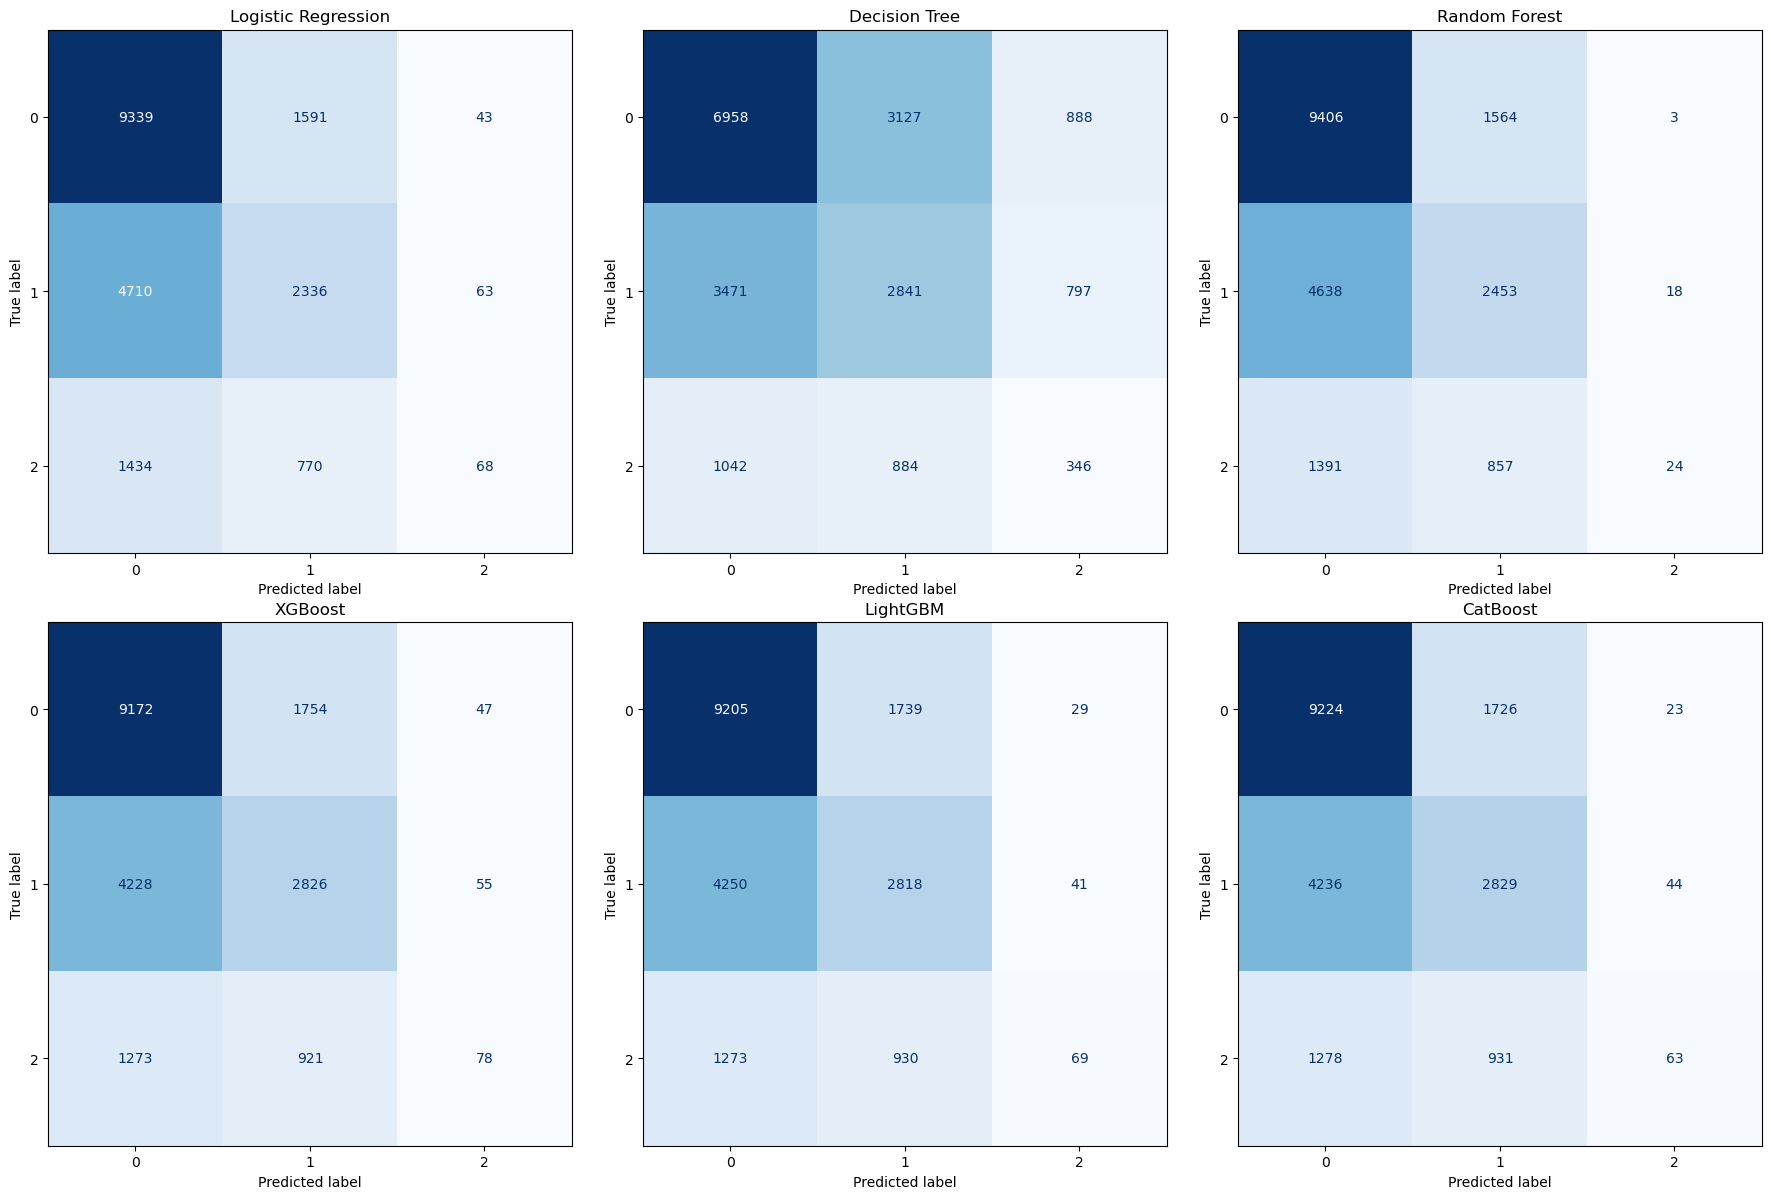

In [20]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, (model_name, pipeline) in zip(axes, trained_models.items()):

    ConfusionMatrixDisplay.from_estimator(
        pipeline,
        X_test,
        y_test,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(model_name)

plt.tight_layout()

plt.show()

## Cell 14 — Select Best Model ##

In [21]:
# Select the best model based on Weighted F1 Score

best_model_name = results_df.iloc[0]["Model"]

best_pipeline = trained_models[best_model_name]

print("=" * 60)
print(f"Best Model: {best_model_name}")
print("=" * 60)

Best Model: CatBoost


## Cell 15 — Save Best Model Information ##

# Final Model Selection

Six machine learning models were evaluated using multiple performance metrics, including Accuracy, Precision, Recall, Weighted F1-Score, Macro F1-Score, ROC-AUC, and Confusion Matrices.

Among all evaluated models, CatBoost achieved the best overall performance with:

- Highest Accuracy (0.5953)
- Highest Weighted F1-Score (0.5496)
- Highest ROC-AUC (0.6952)

Although XGBoost and LightGBM produced very competitive results, CatBoost consistently ranked first across the primary evaluation metrics.

The Confusion Matrix analysis also showed that all models performed well on Class 0 and reasonably on Class 1, while Class 2 remained challenging due to severe class imbalance within the dataset. This limitation was observed consistently across all evaluated algorithms rather than being specific to a single model.

Considering the overall predictive performance, robustness, and ranking across multiple evaluation metrics, **CatBoost** was selected as the final model for the subsequent Explainable AI (XAI) analysis and deployment stages.

In [23]:
best_model_summary = results_df.iloc[[0]]

best_model_summary.to_csv(
    "../reports/best_model_summary.csv",
    index=False
)

best_model_summary

,Model,Accuracy,Precision (Macro),Precision (Weighted),Recall (Macro),Recall (Weighted),F1 Score (Macro),F1 Score (Weighted),ROC AUC
0,CatBoost,0.595264,0.542052,0.571613,0.422095,0.595264,0.406399,0.549573,0.69523


## Cell 16 — Final Conclusion ##

In [22]:
print("=" * 70)
print("MODEL COMPARISON COMPLETED")
print("=" * 70)

print(f"Selected Model : {best_model_name}")

print(f"Accuracy       : {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Weighted F1    : {results_df.iloc[0]['F1 Score (Weighted)']:.4f}")
print(f"ROC AUC        : {results_df.iloc[0]['ROC AUC']:.4f}")

MODEL COMPARISON COMPLETED
Selected Model : CatBoost
Accuracy       : 0.5953
Weighted F1    : 0.5496
ROC AUC        : 0.6952
